In [1]:
# drowsiness_detection.py

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
import shutil

# 1. CHUẨN BỊ DỮ LIỆU
source_root = "D:/Downloads/archive"
target_root = "D:/Downloads/archive_split"
classes = ["Active", "Drowsy"]
split_ratio = 0.2

def prepare_data():
    if not os.path.exists(os.path.join(target_root, 'train')):
        for cls in classes:
            src_dir = os.path.join(source_root, cls)
            all_files = [f for f in os.listdir(src_dir) if f.endswith(('.jpg', '.png'))]
            train_files, val_files = train_test_split(all_files, test_size=split_ratio, random_state=42)
            train_cls_dir = os.path.join(target_root, 'train', cls)
            val_cls_dir = os.path.join(target_root, 'val', cls)
            os.makedirs(train_cls_dir, exist_ok=True)
            os.makedirs(val_cls_dir, exist_ok=True)
            for f in train_files:
                shutil.copy(os.path.join(src_dir, f), os.path.join(train_cls_dir, f))
            for f in val_files:
                shutil.copy(os.path.join(src_dir, f), os.path.join(val_cls_dir, f))
        print("Đã chia dữ liệu thành công.")

In [2]:
prepare_data()

In [3]:
# 2. TIỀN XỬ LÝ DỮ LIỆU
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = os.path.join(target_root, 'train')
val_dir = os.path.join(target_root, 'val')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary')

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary')

Found 3972 images belonging to 2 classes.
Found 994 images belonging to 2 classes.


In [4]:
# 3. XÂY DỰNG MÔ HÌNH
def create_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet')
    base_model.trainable = True
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = create_model()



In [5]:
# 4. COMPILE
model.compile(optimizer=keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])



In [6]:
# 5. HUẤN LUYỆN MÔ HÌNH (sử dụng định dạng .keras)
callbacks = [
    keras.callbacks.ModelCheckpoint("drowsiness_model.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks)



C:\Users\taloc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 594s 4s/step - accuracy: 0.7468 - loss: 0.4819 - val_accuracy: 0.5996 - val_loss: 1.1280
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 566s 5s/step - accuracy: 0.9206 - loss: 0.2002 - val_accuracy: 0.6590 - val_loss: 0.9151
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 713s 6s/step - accuracy: 0.9274 - loss: 0.1673 - val_accuracy: 0.8239 - val_loss: 0.5046
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 797s 6s/step - accuracy: 0.9481 - loss: 0.1297 - val_accuracy: 0.9024 - val_loss: 0.3119
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 544s 4s/step - accuracy: 0.9402 - loss: 0.1401 - val_accuracy: 0.8823 - val_loss: 0.3615
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 552s 4s/step - accuracy: 0.9608 - loss: 0.1099 - val_accuracy: 0.9205 - val_loss: 0.2458
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 544s 4s/step - accuracy: 0.9630 - loss: 0.0972 - val_accuracy: 0.9477 - val_loss: 0.1723
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 507s 4s/step - accuracy: 0.9632 - loss: 0.0894 - val_accu

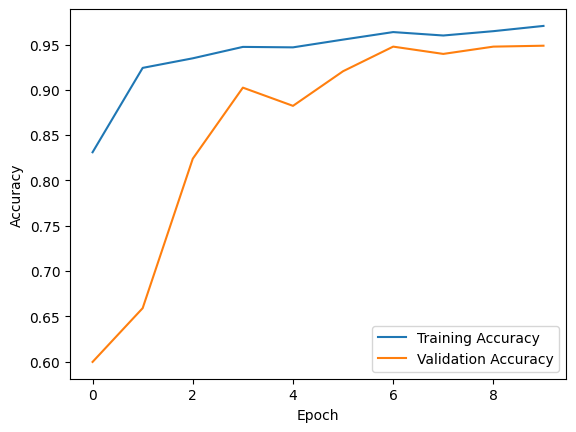

In [9]:
# 6. VẼ BIỂU ĐỒ
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
#7. Đánh giá mô hình
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 905ms/step - accuracy: 0.9580 - loss: 0.1197
Validation Loss: 0.1723
Validation Accuracy: 0.9477
